# Tarea 4

**Autor:** Alejandro Zarate Macias  

**Curso:** Reconocimiento de Patrones (ML)

**Fecha:** 23 de Febrero 2026

---

## Introducción

Esta tarea continúa el estudio del aprendizaje supervisado explorando modelos basados en árboles: Árboles de Decisión (DT) y Random Forests (RF). Se implementan ambos modelos en problemas de regresión y clasificación, utilizando conjuntos de datos reales y funciones analíticas. Se analiza el impacto de distintos hiperparámetros en el desempeño y se compara la capacidad de generalización de cada modelo.

---

## Pre-requisitos

- Python 3.9 o superior
- Librerías:
    - numpy
    - matplotlib
    - notebook
    - pandas
    - scikit-learn
    - kagglehub[pandas-datasets]

---

# Problema 3

Considere el dataset de `2022 Fuel Consumption Ratings`. Cree un script en Python para resolver el problema de regresión de pronóstico del consumo de combustible en ciudad y carretera con `sklearn` usando el modelo `DT`. Anote todos los supuestos, hiperparámetros y operaciones de preprocesamiento de datos que realice.

### Librerías

In [1]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

### Carga de datos

In [2]:
file_path = "MY2022 Fuel Consumption Ratings.csv"

df: pd.DataFrame = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "rinichristy/2022-fuel-consumption-ratings",
    file_path
)

In [3]:
df.head()

,Model Year,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption (City (L/100 km),Fuel Consumption(Hwy (L/100 km)),Fuel Consumption(Comb (L/100 km)),Fuel Consumption(Comb (mpg)),CO2 Emissions(g/km),CO2 Rating,Smog Rating
0,2022,Acura,ILX,Compact,2.4,4,AM8,Z,9.9,7.0,8.6,33,200,6,3
1,2022,Acura,MDX SH-AWD,SUV: Small,3.5,6,AS10,Z,12.6,9.4,11.2,25,263,4,5
2,2022,Acura,RDX SH-AWD,SUV: Small,2.0,4,AS10,Z,11.0,8.6,9.9,29,232,5,6
3,2022,Acura,RDX SH-AWD A-SPEC,SUV: Small,2.0,4,AS10,Z,11.3,9.1,10.3,27,242,5,6
4,2022,Acura,TLX SH-AWD,Compact,2.0,4,AS10,Z,11.2,8.0,9.8,29,230,5,7


### Preprocesamiento de Datos

In [4]:
# Seleccion de features y variables objetivo

# X:
# Variables numericas: 'Engine Size(L)', 'Cylinders'
# Variables categoricas: 'Vehicle Class', 'Transmission', 'Fuel Type'
X = df[['Engine Size(L)', 'Cylinders', 
        'Vehicle Class', 'Transmission', 'Fuel Type']]

# Manejo de variables categoricas con get_dummies
X = pd.get_dummies(X, columns=['Vehicle Class', 'Transmission', 'Fuel Type'], drop_first=True)


# y: Un solo DataFrame con ambas variables objetivo (multi-output)
y = df[['Fuel Consumption (City (L/100 km)', 'Fuel Consumption(Hwy (L/100 km))']]

In [5]:
# Split de datos en entrenamiento y prueba (un solo split para ambas salidas)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14)

# Tamaño de los conjuntos de entrenamiento y prueba
print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras, {X_train.shape[1]} features")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")
print(f"Variables objetivo: {list(y.columns)}")

Conjunto de entrenamiento: 756 muestras, 40 features
Conjunto de prueba: 190 muestras
Variables objetivo: ['Fuel Consumption (City (L/100 km)', 'Fuel Consumption(Hwy (L/100 km))']


### Entrenamiento

In [6]:
# Modelo multi-output (un solo DT para ciudad y carretera)
model = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=14
)
model.fit(X_train, y_train)
print("Modelo multi-output entrenado.")

Modelo multi-output entrenado.


### Evaluación

In [7]:
# Predicciones
y_pred = model.predict(X_test)

# Metricas por salida
y_test_city = y_test.iloc[:, 0]
y_test_hwy = y_test.iloc[:, 1]
y_pred_city = y_pred[:, 0]
y_pred_hwy = y_pred[:, 1]

mse_city = mean_squared_error(y_test_city, y_pred_city)
rmse_city = mse_city ** 0.5
r2_city = r2_score(y_test_city, y_pred_city)

mse_hwy = mean_squared_error(y_test_hwy, y_pred_hwy)
rmse_hwy = mse_hwy ** 0.5
r2_hwy = r2_score(y_test_hwy, y_pred_hwy)

# Tabla de resultados
print('-' * 60)
print(f"{'Salida':<15} {'MSE':<15} {'RMSE':<15} {'R²':<15}")
print('-' * 60)
print(f"{'Ciudad':<15} {mse_city:<15.4f} {rmse_city:<15.4f} {r2_city:<15.4f}")
print(f"{'Carretera':<15} {mse_hwy:<15.4f} {rmse_hwy:<15.4f} {r2_hwy:<15.4f}")
print('-' * 60)

------------------------------------------------------------
Salida          MSE             RMSE            R²             
------------------------------------------------------------
Ciudad          1.5518          1.2457          0.8484         
Carretera       0.8305          0.9113          0.8041         
------------------------------------------------------------


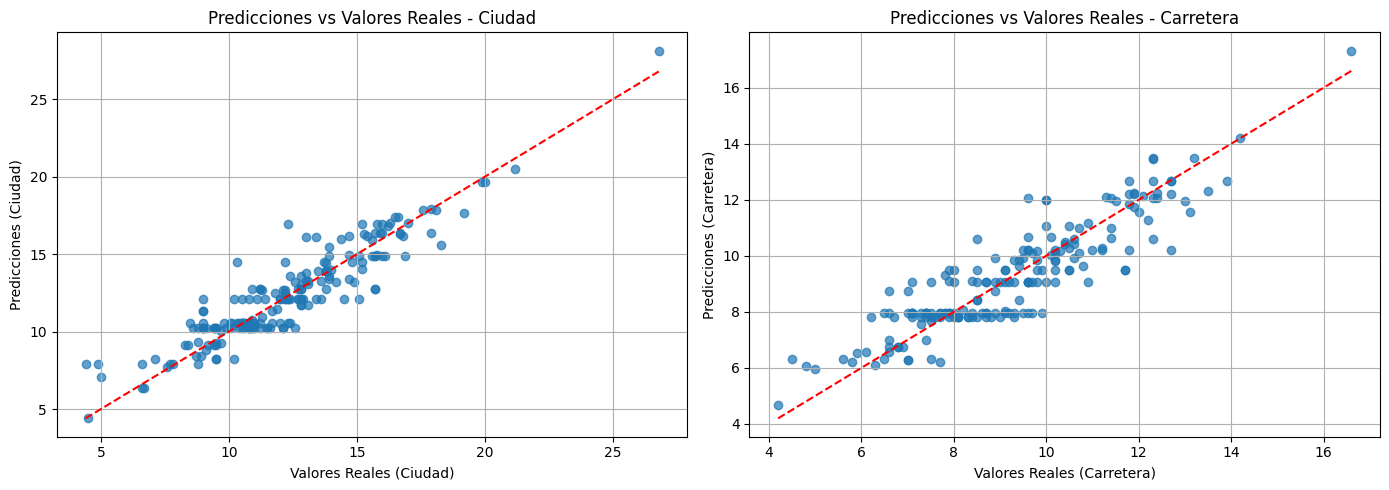

In [8]:
# Gráficas de predicciones vs valores reales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica para Ciudad
axes[0].scatter(y_test_city, y_pred_city, alpha=0.7)
axes[0].plot([y_test_city.min(), y_test_city.max()], [y_test_city.min(), y_test_city.max()], 'r--')
axes[0].set_xlabel('Valores Reales (Ciudad)')
axes[0].set_ylabel('Predicciones (Ciudad)')
axes[0].set_title('Predicciones vs Valores Reales - Ciudad')
axes[0].grid()

# Gráfica para Carretera
axes[1].scatter(y_test_hwy, y_pred_hwy, alpha=0.7)
axes[1].plot([y_test_hwy.min(), y_test_hwy.max()], [y_test_hwy.min(), y_test_hwy.max()], 'r--')
axes[1].set_xlabel('Valores Reales (Carretera)')
axes[1].set_ylabel('Predicciones (Carretera)')
axes[1].set_title('Predicciones vs Valores Reales - Carretera')
axes[1].grid()

plt.tight_layout()
plt.show()

---

# Problema 4

Considere la siguiente función:

$f(x) = 1-2^{\sin(-x^2)}, \quad x \in \mathcal{I}[-\pi, \pi]$

Realice un script en Python para resolver el problema de regresión asociado con un `DT` utilizando `sklearn`. Escriba todas las suposiciones que realice. Además, anote los hiperparámetros que elija y explique por qué los seleccionó de esa manera.

### Librerías

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

### Carga de datos

In [10]:
# Generación de datos sintéticos
np.random.seed(14)
X = np.linspace(-np.pi, np.pi, 5000).reshape(-1, 1)
y = 1 - 2 ** (np.sin(-X.ravel() ** 2))

### Preprocesamiento de Datos

In [11]:
# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

Conjunto de entrenamiento: 4000 muestras
Conjunto de prueba: 1000 muestras


### Entrenamiento

In [12]:
model = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=5,
    random_state=14
)
model.fit(X_train, y_train)
print("Modelo entrenado.")

Modelo entrenado.


### Evaluación

In [13]:
# Métricas
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print('-' * 60)
print(f"{'Modelo':<15} {'MSE':<15} {'RMSE':<15} {'R²':<15}")
print('-' * 60)
print(f"{'f(x)':<15} {mse:<15.4f} {rmse:<15.4f} {r2:<15.4f}")
print('-' * 60)

------------------------------------------------------------
Modelo          MSE             RMSE            R²             
------------------------------------------------------------
f(x)            0.0001          0.0081          0.9997         
------------------------------------------------------------


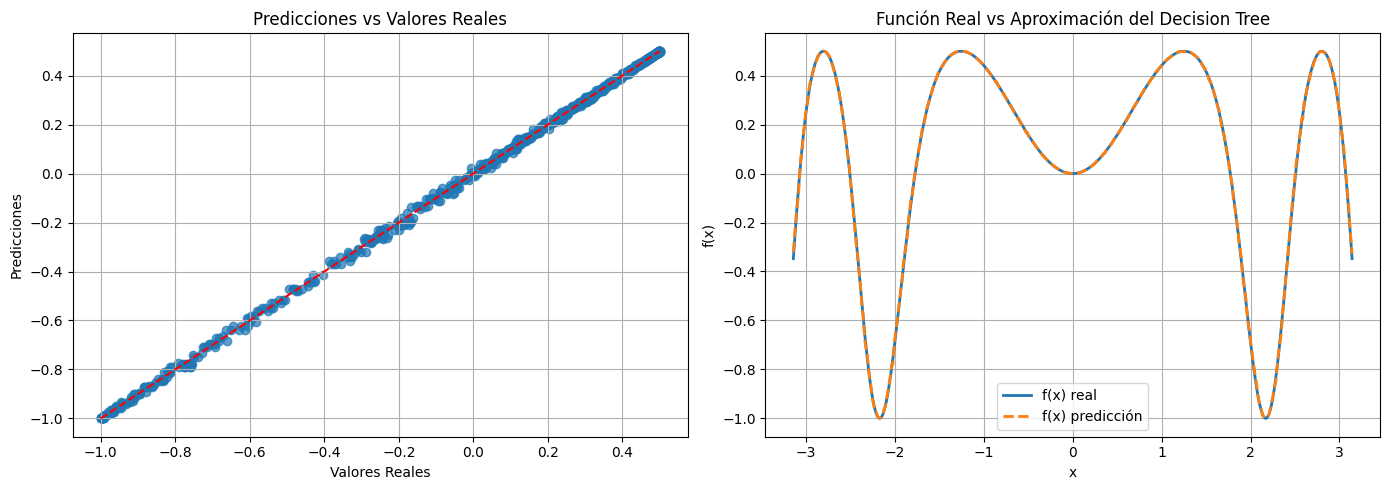

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicciones vs valores reales
axes[0].scatter(y_test, y_pred, alpha=0.7)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Valores Reales')
axes[0].set_ylabel('Predicciones')
axes[0].set_title('Predicciones vs Valores Reales')
axes[0].grid()

# Curva ajustada vs función real
X_plot = np.linspace(-np.pi, np.pi, 500).reshape(-1, 1)
y_plot_real = 1 - 2 ** (np.sin(-X_plot.ravel() ** 2))
y_plot_pred = model.predict(X_plot)

axes[1].plot(X_plot, y_plot_real, label='f(x) real', linewidth=2)
axes[1].plot(X_plot, y_plot_pred, label='f(x) predicción', linewidth=2, linestyle='--')
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].set_title('Función Real vs Aproximación del Decision Tree')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

---

# Problema 5

Considere el conjunto de datos de `horse.csv`. Cree un script con `sklearn` para resolver el problema de clasificación binaria asociado con determinar si un caballo determinado sobrevivirá o no. Utilice un modelo `DT`. Anote todas las suposiciones y operaciones de preprocesamiento de datos que realice. Incorpore el F1 score para explicar sus hallazgos.

### Librerías

In [15]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
from kagglehub import KaggleDatasetAdapter
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

### Carga de datos

In [16]:
file_path = "horse.csv"

df: pd.DataFrame = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "yasserh/horsesurvivalprognostication",
    file_path
)

print(f"Dataset shape: {df.shape}")
print(f"Columnas: {list(df.columns)}")
print(f"\nValores nulos por columna:")
print(df.isnull().sum())

Dataset shape: (299, 28)
Columnas: ['surgery', 'age', 'hospital_number', 'rectal_temp', 'pulse', 'respiratory_rate', 'temp_of_extremities', 'peripheral_pulse', 'mucous_membrane', 'capillary_refill_time', 'pain', 'peristalsis', 'abdominal_distention', 'nasogastric_tube', 'nasogastric_reflux', 'nasogastric_reflux_ph', 'rectal_exam_feces', 'abdomen', 'packed_cell_volume', 'total_protein', 'abdomo_appearance', 'abdomo_protein', 'outcome', 'surgical_lesion', 'lesion_1', 'lesion_2', 'lesion_3', 'cp_data']

Valores nulos por columna:
surgery                    0
age                        0
hospital_number            0
rectal_temp               60
pulse                     24
respiratory_rate          58
temp_of_extremities       56
peripheral_pulse          69
mucous_membrane           47
capillary_refill_time     32
pain                      55
peristalsis               44
abdominal_distention      56
nasogastric_tube         104
nasogastric_reflux       106
nasogastric_reflux_ph    246
rec

### Preprocesamiento de Datos

In [17]:
# Variable objetivo binaria: lived = 1, died/euthanized = 0
df['outcome_binary'] = (df['outcome'] == 'lived').astype(int)
print(f"Distribución de clases:")
print(df['outcome_binary'].value_counts())

# Eliminar columnas no relevantes
cols_to_drop = ['outcome', 'hospital_number', 'lesion_1', 'lesion_2', 'lesion_3', 'cp_data']
df = df.drop(columns=cols_to_drop)

# Separar features y target
X = df.drop('outcome_binary', axis=1)
y = df['outcome_binary']

# Separar columnas numéricas y categóricas
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Imputar valores faltantes
imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')
X[numeric_cols] = imputer_num.fit_transform(X[numeric_cols])
X[categorical_cols] = imputer_cat.fit_transform(X[categorical_cols])

# Codificación one-hot
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

Distribución de clases:
outcome_binary
1    178
0    121
Name: count, dtype: int64


In [18]:
# División
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=14, stratify=y
)

print(f"Conjunto de entrenamiento: {X_train.shape}")
print(f"Conjunto de prueba: {X_test.shape}")

Conjunto de entrenamiento: (239, 46)
Conjunto de prueba: (60, 46)


### Entrenamiento

In [19]:
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=14
)
model.fit(X_train, y_train)
print("Modelo entrenado.")

Modelo entrenado.


### Evaluación

In [20]:
# Métricas
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('-' * 30)
print(f"{'Metrica':<20} {'Valor':<15}")
print('-' * 30)
print(f"{'Accuracy':<20} {acc:<15.4f}")
print(f"{'F1 (clase 1)':<20} {f1:<15.4f}")
print('-' * 30)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=['No sobrevivió', 'Sobrevivió']))

------------------------------
Metrica              Valor          
------------------------------
Accuracy             0.7667         
F1 (clase 1)         0.8205         
------------------------------

Reporte de clasificación:
               precision    recall  f1-score   support

No sobrevivió       0.78      0.58      0.67        24
   Sobrevivió       0.76      0.89      0.82        36

     accuracy                           0.77        60
    macro avg       0.77      0.74      0.74        60
 weighted avg       0.77      0.77      0.76        60



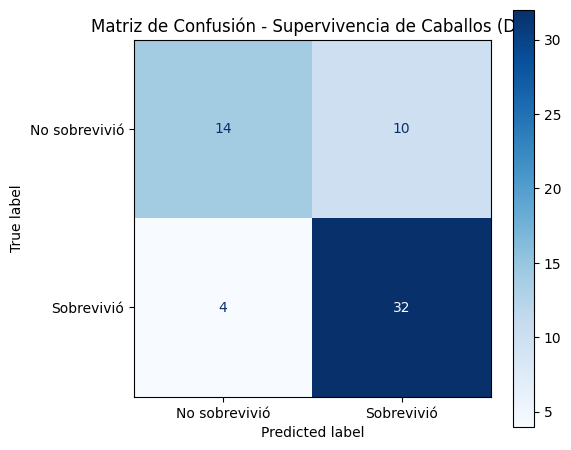

In [21]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No sobrevivió', 'Sobrevivió'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Matriz de Confusión - Supervivencia de Caballos (DT)')
plt.tight_layout()
plt.show()

---

# Problema 6

Considere el conjunto de datos de `beer.csv`. Cree un script con `sklearn` para resolver el problema de clasificación multiclase asociado con la clasificación de cervezas por estilo. Utilice un modelo `DT`. Anote todas las suposiciones y operaciones de preprocesamiento de datos que realice. Luego, incorpore una matriz de confusión en su análisis.

### Librerías

In [22]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

### Carga de datos

In [23]:
file_path = "beer.csv"

df: pd.DataFrame = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "ankurnapa/ankurs-beer-data-set",
    file_path
)

df.head()

,Brew No.,OG,ABV,pH,IBU,style
0,1,11.5,4.2,4.20,14.0,Premium Lager
1,2,12.2,4.8,4.25,12.0,Premium Lager
2,3,13.0,5.0,3.80,13.0,Premium Lager
3,4,11.0,3.9,4.20,14.0,Premium Lager
4,5,12.0,4.2,3.90,12.0,Premium Lager


### Preprocesamiento de Datos

In [24]:
# Separar features y target
X = df.drop(['style', 'Brew No.'], axis=1)
y = df['style']

print(f"Shape: {X.shape}")
print(f"Número de clases: {y.nunique()}")
print(f"Clases: {sorted(y.unique())}")

Shape: (150, 4)
Número de clases: 3
Clases: ['IPA', 'Light Lager', 'Premium Lager']


In [25]:
# División train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.9, random_state=14, stratify=y
)

print(f"Conjunto de entrenamiento: {X_train.shape}")
print(f"Conjunto de prueba: {X_test.shape}")

Conjunto de entrenamiento: (15, 4)
Conjunto de prueba: (135, 4)


### Entrenamiento

In [26]:
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_split=3,
    min_samples_leaf=2,
    random_state=14
)
model.fit(X_train, y_train)
print("Modelo entrenado.")

Modelo entrenado.


### Evaluación

In [27]:
# Métricas
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print('-' * 30)
print(f"{'Metrica':<20} {'Valor':<15}")
print('-' * 30)
print(f"{'Accuracy':<20} {acc:<15.4f}")
print(f"{'F1 (macro)':<20} {f1_macro:<15.4f}")
print(f"{'F1 (weighted)':<20} {f1_weighted:<15.4f}")
print('-' * 30)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=sorted(y.unique())))

------------------------------
Metrica              Valor          
------------------------------
Accuracy             0.9704         
F1 (macro)           0.9704         
F1 (weighted)        0.9704         
------------------------------

Reporte de clasificación:
               precision    recall  f1-score   support

          IPA       1.00      0.98      0.99        45
  Light Lager       0.98      0.93      0.95        45
Premium Lager       0.94      1.00      0.97        45

     accuracy                           0.97       135
    macro avg       0.97      0.97      0.97       135
 weighted avg       0.97      0.97      0.97       135



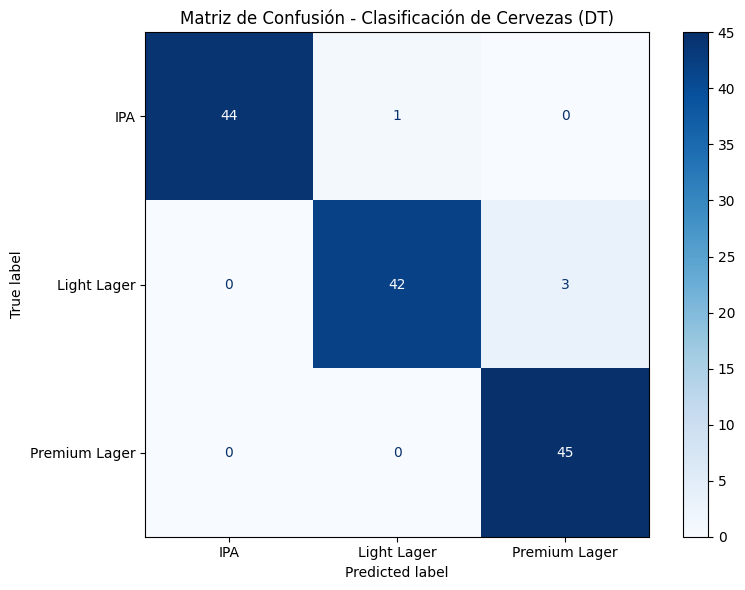

In [28]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Matriz de Confusión - Clasificación de Cervezas (DT)')
plt.tight_layout()
plt.show()

---

# Problema 7

Considere la ecuación cuadrática general

$ax^2 + bx + c = 0$

Haga su mejor esfuerzo para clasificar las raíces de la ecuación anterior en términos de sus coeficientes utilizando un modelo `DT` con `sklearn`. Para simplificar, debe fijar el dominio para $x$ y proponer un dominio adecuado para los coeficientes. Escriba todas sus suposiciones y muestre sus hallazgos utilizando algunas gráficas.

### Librerías

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

### Carga de datos

In [30]:
np.random.seed(14)

def generate_quadratic_data(n_samples=3000):
    data = []
    samples_per_class = n_samples // 3

    # Clase 2: Raíces reales distintas (Δ > 0)
    count = 0
    while count < samples_per_class:
        a = np.random.uniform(-10, 10)
        while abs(a) < 0.1:
            a = np.random.uniform(-10, 10)
        b = np.random.uniform(-10, 10)
        max_c = (b**2) / (4 * abs(a)) - 0.1
        c = np.random.uniform(-10, min(10, max_c))
        discriminant = b**2 - 4*a*c
        if discriminant > 0:
            data.append([a, b, c, 2])
            count += 1

    # Clase 1: Raíz real doble (Δ ≈ 0)
    count = 0
    while count < samples_per_class:
        a = np.random.uniform(-10, 10)
        while abs(a) < 0.1:
            a = np.random.uniform(-10, 10)
        b = np.random.uniform(-10, 10)
        c = (b**2) / (4 * a) + np.random.uniform(-0.05, 0.05)
        data.append([a, b, c, 1])
        count += 1

    # Clase 0: Raíces complejas (Δ < 0)
    count = 0
    while count < samples_per_class:
        a = np.random.uniform(-10, 10)
        while abs(a) < 0.1:
            a = np.random.uniform(-10, 10)
        b = np.random.uniform(-10, 10)
        min_c = (b**2) / (4 * abs(a)) + 0.1
        c = np.random.uniform(min(min_c, 10), 10)
        discriminant = b**2 - 4*a*c
        if discriminant < 0:
            data.append([a, b, c, 0])
            count += 1

    return pd.DataFrame(data, columns=['a', 'b', 'c', 'root_type'])

df = generate_quadratic_data(n_samples=3000)

print(f"Dataset generado: {df.shape[0]} ecuaciones cuadráticas")
print(f"Distribución por clase:")
print(df['root_type'].value_counts().sort_index())

Dataset generado: 3000 ecuaciones cuadráticas
Distribución por clase:
root_type
0    1000
1    1000
2    1000
Name: count, dtype: int64


### Preprocesamiento de Datos

In [31]:
# Separar features y target
X = df[['a', 'b', 'c']]
y = df['root_type']

# División train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=14, stratify=y
)

print(f"\nConjunto de entrenamiento: {X_train.shape}")
print(f"Conjunto de prueba: {X_test.shape}")


Conjunto de entrenamiento: (2400, 3)
Conjunto de prueba: (600, 3)


### Entrenamiento

In [32]:
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=14
)

model.fit(X_train, y_train)
print("Modelo entrenado.")

Modelo entrenado.


### Evaluación

In [33]:
# Métricas
y_pred = model.predict(X_test)
class_names = ['Complejas\n(Δ<0)', 'Doble\n(Δ≈0)', 'Reales\n(Δ>0)']

train_acc = accuracy_score(y_train, model.predict(X_train))
train_f1 = f1_score(y_train, model.predict(X_train), average='weighted')
test_acc = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='weighted')

print("-" * 42)
print("Resultados del Modelo DT")
print("-" * 42)
print(f"Train Accuracy: {train_acc:.4f}, Train F1: {train_f1:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}, Test F1:  {test_f1:.4f}")
print("-" * 42)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred,
                            target_names=['Complejas', 'Doble', 'Reales distintas']))

------------------------------------------
Resultados del Modelo DT
------------------------------------------
Train Accuracy: 0.9650, Train F1: 0.9650
Test Accuracy:  0.8850, Test F1:  0.8849
------------------------------------------

Reporte de clasificación:
                  precision    recall  f1-score   support

       Complejas       0.88      0.93      0.90       200
           Doble       0.84      0.83      0.84       200
Reales distintas       0.94      0.90      0.92       200

        accuracy                           0.89       600
       macro avg       0.89      0.89      0.88       600
    weighted avg       0.89      0.89      0.88       600



<Figure size 800x600 with 0 Axes>

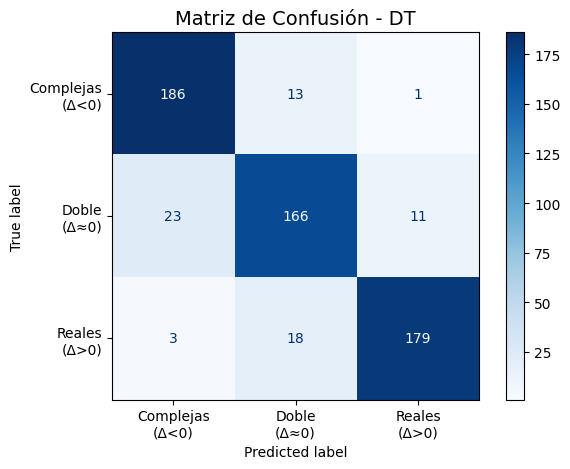

In [34]:
# Matriz de confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión - DT', fontsize=14)
plt.tight_layout()
plt.show()

---

# Problema 8

Repite el problema 3 utilizando un modelo `RF` en lugar de `DT`. Anota todos los hiperparámetros que elijas y todas tus suposiciones.

### Librerías

In [35]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

### Carga de datos

In [36]:
file_path = "MY2022 Fuel Consumption Ratings.csv"

df: pd.DataFrame = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "rinichristy/2022-fuel-consumption-ratings",
    file_path
)

df.head()

,Model Year,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption (City (L/100 km),Fuel Consumption(Hwy (L/100 km)),Fuel Consumption(Comb (L/100 km)),Fuel Consumption(Comb (mpg)),CO2 Emissions(g/km),CO2 Rating,Smog Rating
0,2022,Acura,ILX,Compact,2.4,4,AM8,Z,9.9,7.0,8.6,33,200,6,3
1,2022,Acura,MDX SH-AWD,SUV: Small,3.5,6,AS10,Z,12.6,9.4,11.2,25,263,4,5
2,2022,Acura,RDX SH-AWD,SUV: Small,2.0,4,AS10,Z,11.0,8.6,9.9,29,232,5,6
3,2022,Acura,RDX SH-AWD A-SPEC,SUV: Small,2.0,4,AS10,Z,11.3,9.1,10.3,27,242,5,6
4,2022,Acura,TLX SH-AWD,Compact,2.0,4,AS10,Z,11.2,8.0,9.8,29,230,5,7


### Preprocesamiento de Datos

In [37]:
# Selección de features y variables objetivo
X = df[['Engine Size(L)', 'Cylinders',
        'Vehicle Class', 'Transmission', 'Fuel Type']]
X = pd.get_dummies(X, columns=['Vehicle Class', 'Transmission', 'Fuel Type'], drop_first=True)

# y: Un solo DataFrame con ambas variables objetivo (multi-output)
y = df[['Fuel Consumption (City (L/100 km)', 'Fuel Consumption(Hwy (L/100 km))']]

In [38]:
# División de datos (un solo split para ambas salidas)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=14)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras, {X_train.shape[1]} features")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")
print(f"Variables objetivo: {list(y.columns)}")

Conjunto de entrenamiento: 756 muestras, 40 features
Conjunto de prueba: 190 muestras
Variables objetivo: ['Fuel Consumption (City (L/100 km)', 'Fuel Consumption(Hwy (L/100 km))']


### Entrenamiento

In [39]:
# Modelo multi-output (un solo RF para ciudad y carretera)
model = RandomForestRegressor(
    n_estimators=100,
    criterion='squared_error',
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=14,
    n_jobs=-1
)
model.fit(X_train, y_train)
print("Modelo multi-output entrenado.")

Modelo multi-output entrenado.


### Evaluación

In [40]:
# Predicciones
y_pred = model.predict(X_test)

# Metricas por salida
y_test_city = y_test.iloc[:, 0]
y_test_hwy = y_test.iloc[:, 1]
y_pred_city = y_pred[:, 0]
y_pred_hwy = y_pred[:, 1]

mse_city = mean_squared_error(y_test_city, y_pred_city)
rmse_city = mse_city ** 0.5
r2_city = r2_score(y_test_city, y_pred_city)

mse_hwy = mean_squared_error(y_test_hwy, y_pred_hwy)
rmse_hwy = mse_hwy ** 0.5
r2_hwy = r2_score(y_test_hwy, y_pred_hwy)

print('-' * 60)
print(f"{'Salida':<15} {'MSE':<15} {'RMSE':<15} {'R²':<15}")
print('-' * 60)
print(f"{'Ciudad':<15} {mse_city:<15.4f} {rmse_city:<15.4f} {r2_city:<15.4f}")
print(f"{'Carretera':<15} {mse_hwy:<15.4f} {rmse_hwy:<15.4f} {r2_hwy:<15.4f}")
print('-' * 60)

------------------------------------------------------------
Salida          MSE             RMSE            R²             
------------------------------------------------------------
Ciudad          1.1858          1.0889          0.8842         
Carretera       0.7618          0.8728          0.8203         
------------------------------------------------------------


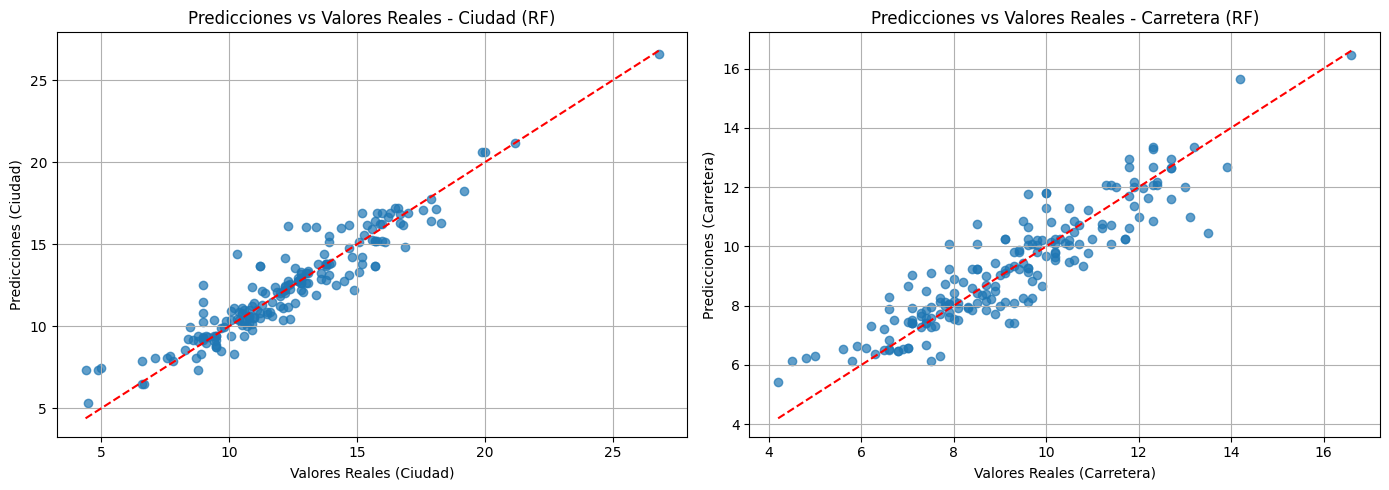

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_city, y_pred_city, alpha=0.7)
axes[0].plot([y_test_city.min(), y_test_city.max()],
             [y_test_city.min(), y_test_city.max()], 'r--')
axes[0].set_xlabel('Valores Reales (Ciudad)')
axes[0].set_ylabel('Predicciones (Ciudad)')
axes[0].set_title('Predicciones vs Valores Reales - Ciudad (RF)')
axes[0].grid()

axes[1].scatter(y_test_hwy, y_pred_hwy, alpha=0.7)
axes[1].plot([y_test_hwy.min(), y_test_hwy.max()],
             [y_test_hwy.min(), y_test_hwy.max()], 'r--')
axes[1].set_xlabel('Valores Reales (Carretera)')
axes[1].set_ylabel('Predicciones (Carretera)')
axes[1].set_title('Predicciones vs Valores Reales - Carretera (RF)')
axes[1].grid()

plt.tight_layout()
plt.show()

---

# Problema 9

Repite el problema 4 utilizando un modelo `RF` en lugar de `DT`. Anota todos los hiperparámetros que elijas y todas tus suposiciones.

### Librerías

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

### Carga de datos

In [43]:
# Generación de datos sintéticos
np.random.seed(14)
X = np.linspace(-np.pi, np.pi, 5000).reshape(-1, 1)
y = 1 - 2 ** (np.sin(-X.ravel() ** 2))

### Preprocesamiento de Datos

In [44]:
# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=14)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

Conjunto de entrenamiento: 4000 muestras
Conjunto de prueba: 1000 muestras


### Entrenamiento

In [45]:
model = RandomForestRegressor(
    n_estimators=100,
    criterion='squared_error',
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=14,
    n_jobs=-1
)
model.fit(X_train, y_train)
print("Modelo entrenado.")

Modelo entrenado.


### Evaluación

In [46]:
# Métricas
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print('-' * 60)
print(f"{'Modelo':<15} {'MSE':<15} {'RMSE':<15} {'R²':<15}")
print('-' * 60)
print(f"{'f(x)':<15} {mse:<15.4f} {rmse:<15.4f} {r2:<15.4f}")
print('-' * 60)

------------------------------------------------------------
Modelo          MSE             RMSE            R²             
------------------------------------------------------------
f(x)            0.0000          0.0024          1.0000         
------------------------------------------------------------


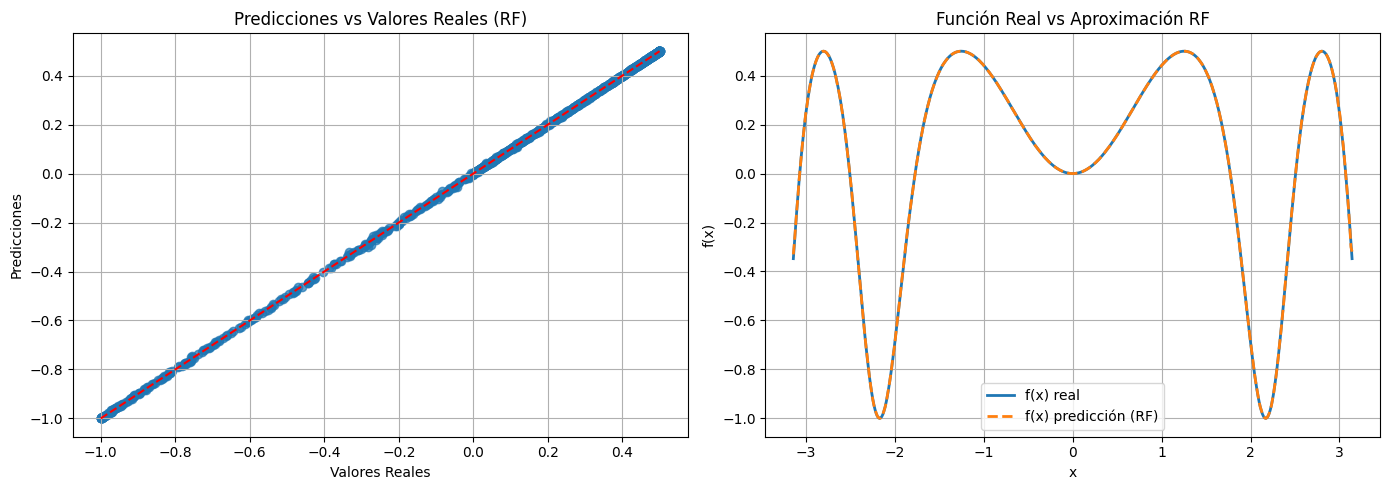

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicciones vs valores reales
axes[0].scatter(y_test, y_pred, alpha=0.7)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Valores Reales')
axes[0].set_ylabel('Predicciones')
axes[0].set_title('Predicciones vs Valores Reales (RF)')
axes[0].grid()

# Curva ajustada vs función real
X_plot = np.linspace(-np.pi, np.pi, 500).reshape(-1, 1)
y_plot_real = 1 - 2 ** (np.sin(-X_plot.ravel() ** 2))
y_plot_pred = model.predict(X_plot)

axes[1].plot(X_plot, y_plot_real, label='f(x) real', linewidth=2)
axes[1].plot(X_plot, y_plot_pred, label='f(x) predicción (RF)', linewidth=2, linestyle='--')
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].set_title('Función Real vs Aproximación RF')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

---

# Problema 10

Repite el problema 5 utilizando un modelo `RF` en lugar de `DT`. Anota todos los hiperparámetros que elijas y todas tus suposiciones.

### Librerías

In [48]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
from kagglehub import KaggleDatasetAdapter
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

### Carga de datos

In [49]:
file_path = "horse.csv"

df: pd.DataFrame = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "yasserh/horsesurvivalprognostication",
    file_path
)

### Preprocesamiento de Datos

In [50]:
# Variable objetivo binaria
df['outcome_binary'] = (df['outcome'] == 'lived').astype(int)

# Eliminar columnas no relevantes
cols_to_drop = ['outcome', 'hospital_number', 'lesion_1', 'lesion_2', 'lesion_3', 'cp_data']
df = df.drop(columns=cols_to_drop)

# Separar features y target
X = df.drop('outcome_binary', axis=1)
y = df['outcome_binary']

# Imputar valores faltantes
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')
X[numeric_cols] = imputer_num.fit_transform(X[numeric_cols])
X[categorical_cols] = imputer_cat.fit_transform(X[categorical_cols])

# Codificación one-hot
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [51]:
# División
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=14, stratify=y)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

Conjunto de entrenamiento: 239 muestras
Conjunto de prueba: 60 muestras


### Entrenamiento

In [52]:
model = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=14,
    n_jobs=-1
)
model.fit(X_train, y_train)
print("Modelo entrenado.")

Modelo entrenado.


### Evaluación

In [53]:
# Métricas
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

print('-' * 30)
print(f"{'Metrica':<20} {'Valor':<15}")
print('-' * 30)
print(f"{'Accuracy':<20} {acc:<15.4f}")
print(f"{'F1 (clase 1)':<20} {f1:<15.4f}")
print(f"{'F1 (macro)':<20} {f1_macro:<15.4f}")
print('-' * 30)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=['No sobrevivió', 'Sobrevivió']))

------------------------------
Metrica              Valor          
------------------------------
Accuracy             0.8000         
F1 (clase 1)         0.8421         
F1 (macro)           0.7847         
------------------------------

Reporte de clasificación:
               precision    recall  f1-score   support

No sobrevivió       0.80      0.67      0.73        24
   Sobrevivió       0.80      0.89      0.84        36

     accuracy                           0.80        60
    macro avg       0.80      0.78      0.78        60
 weighted avg       0.80      0.80      0.80        60



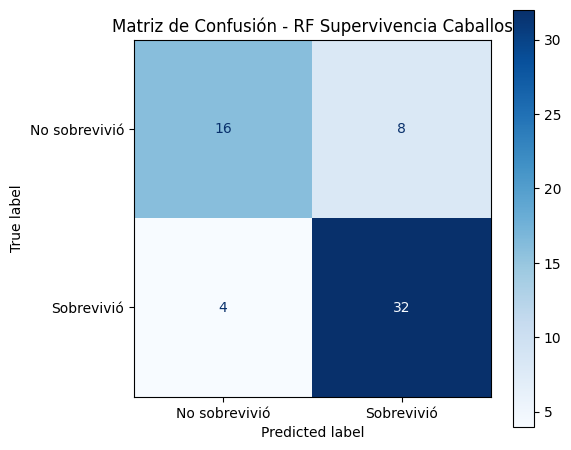

In [54]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No sobrevivió', 'Sobrevivió'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Matriz de Confusión - RF Supervivencia Caballos')
plt.tight_layout()
plt.show()

---

# Problema 11

Repite el problema 6 utilizando un modelo `RF` en lugar de `DT`. Anota todos los hiperparámetros que elijas y todas tus suposiciones.

### Librerías

In [55]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder

### Carga de datos

In [56]:
file_path = "beer.csv"

df: pd.DataFrame = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "ankurnapa/ankurs-beer-data-set",
    file_path
)
df.head()

,Brew No.,OG,ABV,pH,IBU,style
0,1,11.5,4.2,4.20,14.0,Premium Lager
1,2,12.2,4.8,4.25,12.0,Premium Lager
2,3,13.0,5.0,3.80,13.0,Premium Lager
3,4,11.0,3.9,4.20,14.0,Premium Lager
4,5,12.0,4.2,3.90,12.0,Premium Lager


### Preprocesamiento de Datos

In [57]:
# Features y target
X = df[['OG', 'ABV', 'pH', 'IBU']]
y = df['style']

# Codificar target
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

# División train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.9, random_state=14, stratify=y_encoded)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

Conjunto de entrenamiento: 15 muestras
Conjunto de prueba: 135 muestras


### Entrenamiento

In [58]:
model = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=15,
    min_samples_split=3,
    min_samples_leaf=2,
    random_state=14,
    n_jobs=-1
)
model.fit(X_train, y_train)
print("Modelo entrenado.")

Modelo entrenado.


### Evaluación

In [59]:
# Métricas
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print('-' * 30)
print(f"{'Metrica':<20} {'Valor':<15}")
print('-' * 30)
print(f"{'Accuracy':<20} {acc:<15.4f}")
print(f"{'F1 (macro)':<20} {f1_macro:<15.4f}")
print(f"{'F1 (weighted)':<20} {f1_weighted:<15.4f}")
print('-' * 30)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=class_names))

------------------------------
Metrica              Valor          
------------------------------
Accuracy             0.9926         
F1 (macro)           0.9926         
F1 (weighted)        0.9926         
------------------------------

Reporte de clasificación:
               precision    recall  f1-score   support

          IPA       1.00      1.00      1.00        45
  Light Lager       0.98      1.00      0.99        45
Premium Lager       1.00      0.98      0.99        45

     accuracy                           0.99       135
    macro avg       0.99      0.99      0.99       135
 weighted avg       0.99      0.99      0.99       135



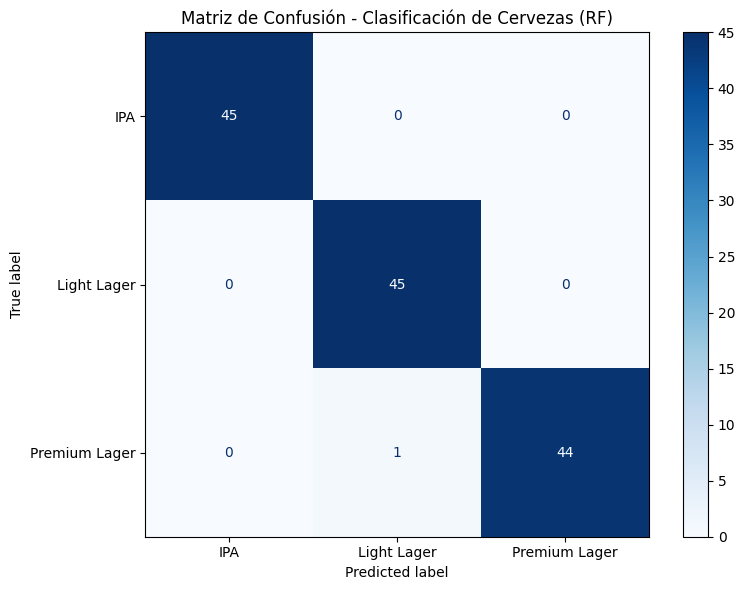

In [60]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Matriz de Confusión - Clasificación de Cervezas (RF)')
plt.tight_layout()
plt.show()

---

# Problema 12

Repite el problema 7 utilizando un modelo `RF` en lugar de `DT`. Anota todos los hiperparámetros que elijas y todas tus suposiciones.

### Librerías

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

### Carga de datos

In [62]:
np.random.seed(14)

def generate_quadratic_data(n_samples=3000):
    data = []
    samples_per_class = n_samples // 3

    # Clase 2: Raíces reales distintas (Δ > 0)
    count = 0
    while count < samples_per_class:
        a = np.random.uniform(-10, 10)
        while abs(a) < 0.1:
            a = np.random.uniform(-10, 10)
        b = np.random.uniform(-10, 10)
        max_c = (b**2) / (4 * abs(a)) - 0.1
        c = np.random.uniform(-10, min(10, max_c))
        discriminant = b**2 - 4*a*c
        if discriminant > 0:
            data.append([a, b, c, 2])
            count += 1

    # Clase 1: Raíz real doble (Δ ≈ 0)
    count = 0
    while count < samples_per_class:
        a = np.random.uniform(-10, 10)
        while abs(a) < 0.1:
            a = np.random.uniform(-10, 10)
        b = np.random.uniform(-10, 10)
        c = (b**2) / (4 * a) + np.random.uniform(-0.05, 0.05)
        data.append([a, b, c, 1])
        count += 1

    # Clase 0: Raíces complejas (Δ < 0)
    count = 0
    while count < samples_per_class:
        a = np.random.uniform(-10, 10)
        while abs(a) < 0.1:
            a = np.random.uniform(-10, 10)
        b = np.random.uniform(-10, 10)
        min_c = (b**2) / (4 * abs(a)) + 0.1
        c = np.random.uniform(min(min_c, 10), 10)
        discriminant = b**2 - 4*a*c
        if discriminant < 0:
            data.append([a, b, c, 0])
            count += 1

    df = pd.DataFrame(data, columns=['a', 'b', 'c', 'root_type'])
    return df

# Generar dataset
df = generate_quadratic_data(n_samples=3000)

print(f"Dataset generado: {df.shape[0]} ecuaciones cuadráticas")
print(f"Distribución por clase:")
print(df['root_type'].value_counts().sort_index())

Dataset generado: 3000 ecuaciones cuadráticas
Distribución por clase:
root_type
0    1000
1    1000
2    1000
Name: count, dtype: int64


### Preprocesamiento de Datos

In [63]:
# Separar features y target
X = df[['a', 'b', 'c']]
y = df['root_type']

# División train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=14, stratify=y
)

print(f"\nConjunto de entrenamiento: {X_train.shape}")
print(f"Conjunto de prueba: {X_test.shape}")


Conjunto de entrenamiento: (2400, 3)
Conjunto de prueba: (600, 3)


### Entrenamiento

In [64]:
model = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=14,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Modelo entrenado.")

Modelo entrenado.


### Evaluación

In [65]:
# Métricas
y_pred = model.predict(X_test)
class_names = ['Complejas\n(Δ<0)', 'Doble\n(Δ≈0)', 'Reales\n(Δ>0)']

train_acc = accuracy_score(y_train, model.predict(X_train))
train_f1 = f1_score(y_train, model.predict(X_train), average='weighted')
test_acc = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='weighted')

print("-" * 42)
print("Resultados del Modelo RF")
print("-" * 42)
print(f"Train Accuracy: {train_acc:.4f}, Train F1: {train_f1:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}, Test F1:  {test_f1:.4f}")
print("-" * 42)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred,
                            target_names=['Complejas', 'Doble', 'Reales distintas']))

------------------------------------------
Resultados del Modelo RF
------------------------------------------
Train Accuracy: 0.9708, Train F1: 0.9709
Test Accuracy:  0.9067, Test F1:  0.9070
------------------------------------------

Reporte de clasificación:
                  precision    recall  f1-score   support

       Complejas       0.88      0.96      0.92       200
           Doble       0.87      0.88      0.87       200
Reales distintas       0.98      0.89      0.93       200

        accuracy                           0.91       600
       macro avg       0.91      0.91      0.91       600
    weighted avg       0.91      0.91      0.91       600



<Figure size 800x600 with 0 Axes>

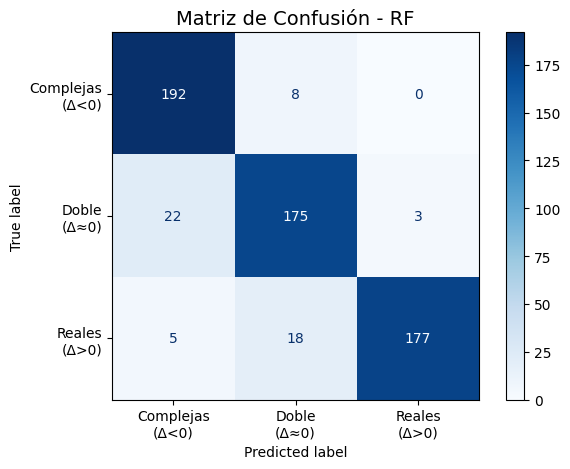

In [66]:
# Matriz de confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión - RF', fontsize=14)
plt.tight_layout()
plt.show()